# Exploratory Data Analysis (EDA):

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


df = pd.read_csv("/content/healthcare-stroke-data.csv")
print(df.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [2]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [3]:
df['gender'].value_counts()

,count
gender,
Female,2994
Male,2115
Other,1


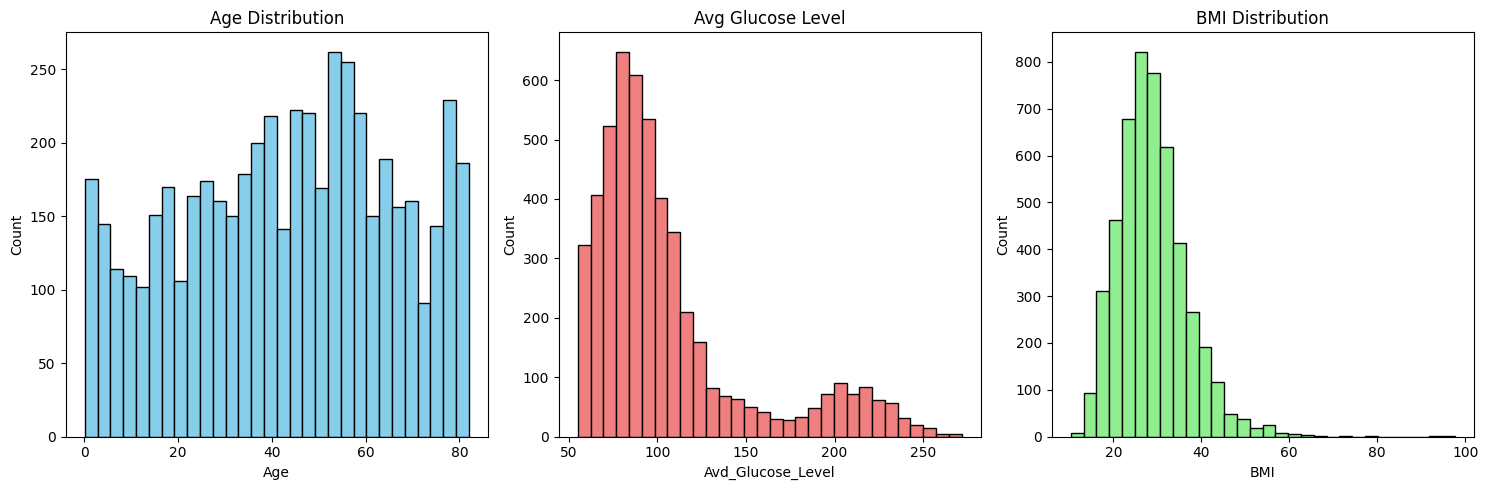

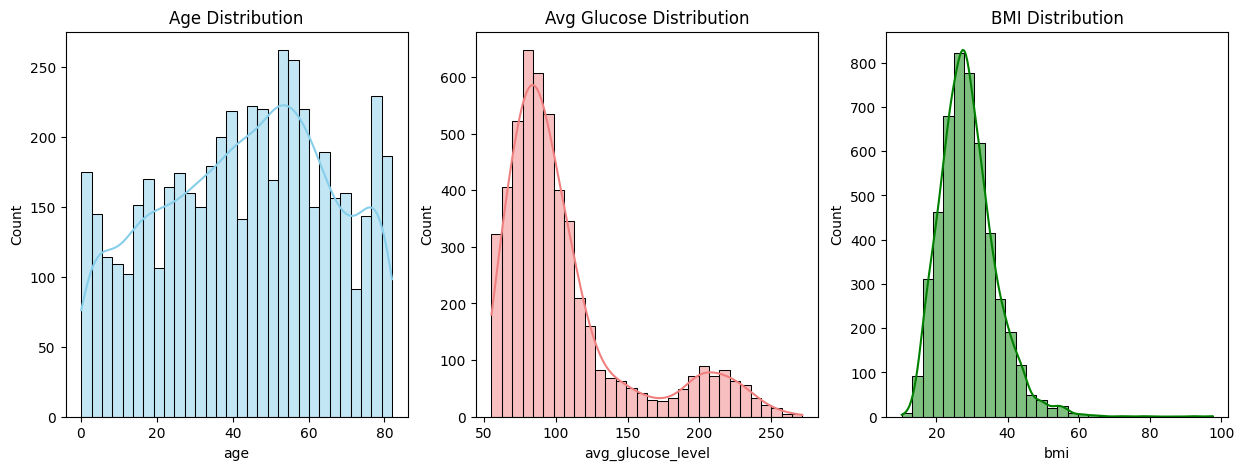

In [4]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.hist(df['age'],bins = 30,color = 'skyblue',edgecolor = 'black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')


plt.subplot(1,3,2)
plt.hist(df['avg_glucose_level'],bins = 30, color ='lightcoral', edgecolor = 'black')
plt.title('Avg Glucose Level')
plt.xlabel('Avd_Glucose_Level')
plt.ylabel('Count')

plt.subplot(1,3,3)
plt.hist(df['bmi'],bins = 30, color ='lightgreen', edgecolor = 'black')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['age'],bins = 30,color ='skyblue' , kde = True)
plt.title('Age Distribution')

plt.subplot(1,3,2)
sns.histplot(df['avg_glucose_level'], bins = 30,color ='lightcoral',kde = True)
plt.title('Avg Glucose Distribution')


plt.subplot(1,3,3)
sns.histplot(df['bmi'],bins = 30,color ='green',kde = True)
plt.title('BMI Distribution')
plt.show()

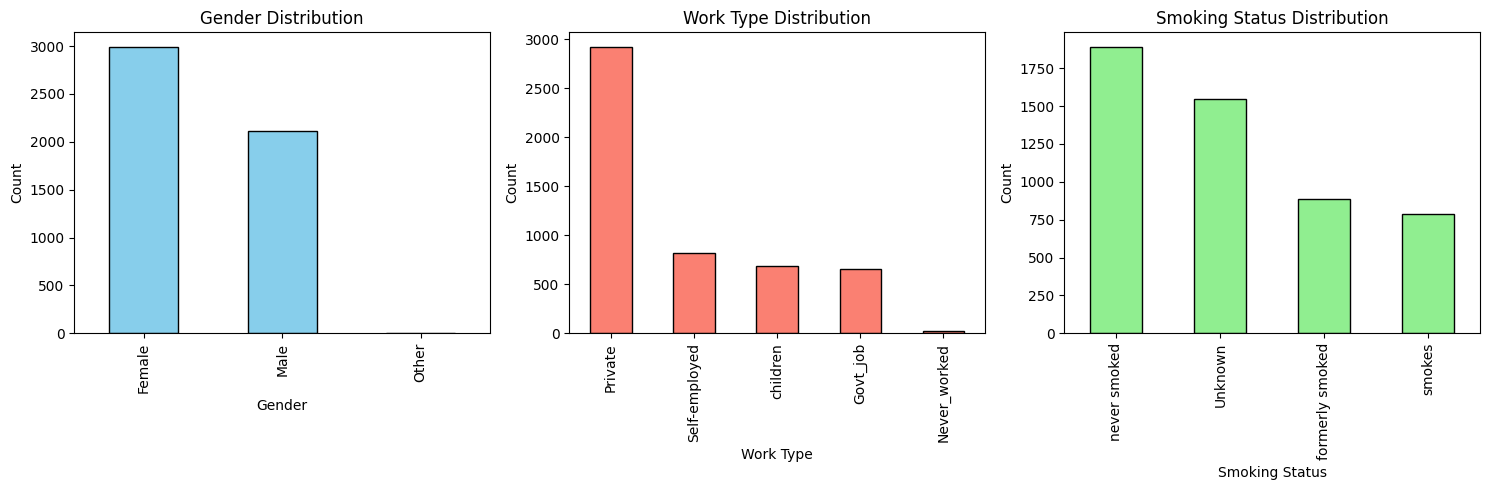

In [5]:
# Setting up the figure for bar charts
plt.figure(figsize=(15, 5))



# Gender distribution
plt.subplot(1, 3, 1)
df['gender'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')


#---------------------------------------------------------------------------
# Work Type distribution
plt.subplot(1, 3, 2)
df['work_type'].value_counts().plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Work Type Distribution')
plt.xlabel('Work Type')
plt.ylabel('Count')

#----------------------------------------------------------------


# Smoking Status distribution
plt.subplot(1, 3, 3)
df['smoking_status'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Smoking Status Distribution')
plt.xlabel('Smoking Status')
plt.ylabel('Count')

# Display the plot
plt.tight_layout()
plt.show()


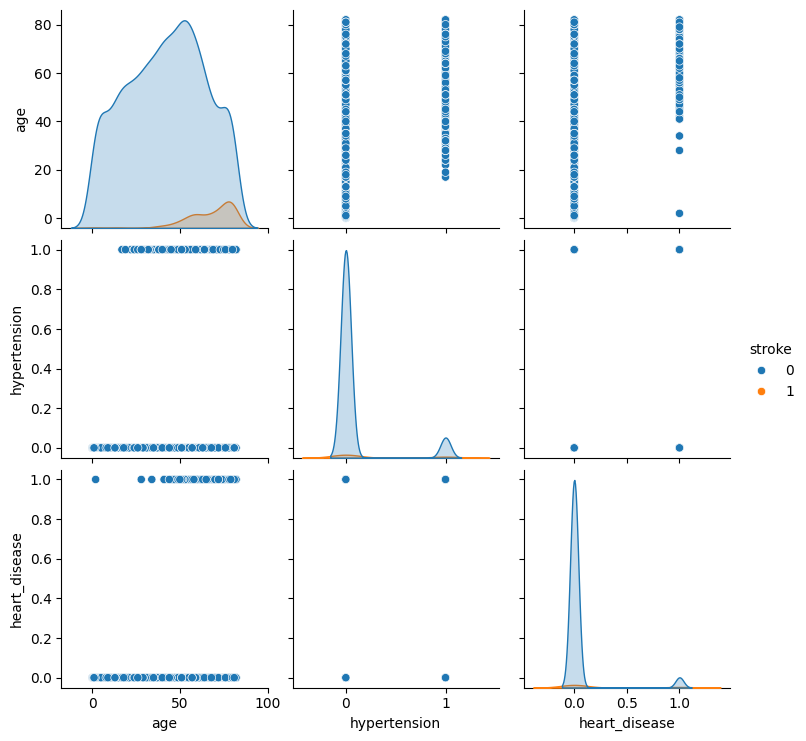

In [6]:
sns.pairplot(df[['age', 'hypertension', 'heart_disease', 'stroke']], hue='stroke')
plt.show()

# Data Preprocessing:

In [7]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)  # Replace missing BMI with median
df['smoking_status'].fillna('Unknown', inplace=True)

<ipython-input-7-3188247b3b11>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)  # Replace missing BMI with median
<ipython-input-7-3188247b3b11>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].met

In [8]:
label_encoder = LabelEncoder()
df['gender'] = label_encoder.fit_transform(df['gender'])
df['ever_married'] = label_encoder.fit_transform(df['ever_married'])
df['work_type'] = label_encoder.fit_transform(df['work_type'])
df['Residence_type'] = label_encoder.fit_transform(df['Residence_type'])
df['smoking_status'] = label_encoder.fit_transform(df['smoking_status'])

In [9]:
scaler = StandardScaler()
df[['age', 'avg_glucose_level', 'bmi']] = scaler.fit_transform(df[['age', 'avg_glucose_level', 'bmi']])

# Predictive Modeling:

In [10]:
# Define features and target
X = df.drop(['stroke', 'id'], axis=1)
y = df['stroke']


In [11]:
from sklearn.metrics import accuracy_score
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Define models and parameters
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}
params = {
    'Decision Tree': {'max_depth': [5, 10, 15, 20]},
    'Random Forest': {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, 15]},
    'K-Nearest Neighbors': {'n_neighbors': [5, 10, 15]}
}

# Train and evaluate models
results = {}
for model_name, model in models.items():
    grid_search = GridSearchCV(model, params[model_name], cv=5, scoring='f1')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    models[model_name] = best_model  # Update the model with the best estimator
    y_pred = best_model.predict(X_test)

    # Store performance metrics
    results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'roc_auc_score': roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
    }

    print(f"Model: {model_name}")
    print(f"Accuracy: {results[model_name]['accuracy']}")
    print(results[model_name]['classification_report'])
    print(f"ROC AUC Score: {results[model_name]['roc_auc_score']}\n")

Model: Decision Tree
Accuracy: 0.9047619047619048
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1458
           1       0.16      0.23      0.19        75

    accuracy                           0.90      1533
   macro avg       0.56      0.58      0.57      1533
weighted avg       0.92      0.90      0.91      1533

ROC AUC Score: 0.5831550068587106

Model: Random Forest
Accuracy: 0.949119373776908
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1458
           1       0.20      0.01      0.03        75

    accuracy                           0.95      1533
   macro avg       0.58      0.51      0.50      1533
weighted avg       0.91      0.95      0.93      1533

ROC AUC Score: 0.8062962962962962

Model: K-Nearest Neighbors
Accuracy: 0.9458577951728636
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1458
           1

# Final Visualization

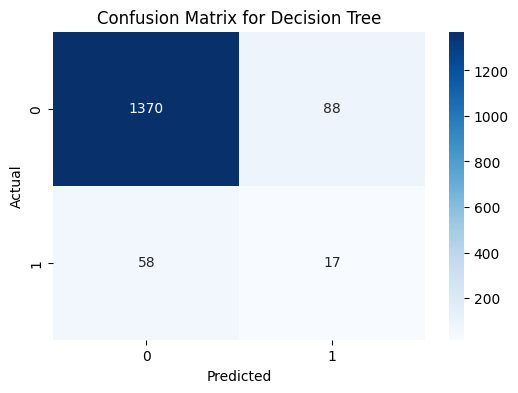

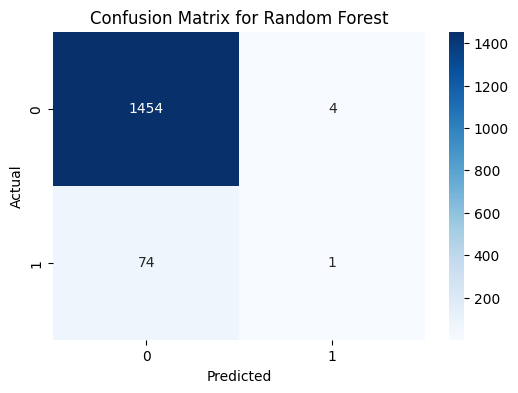

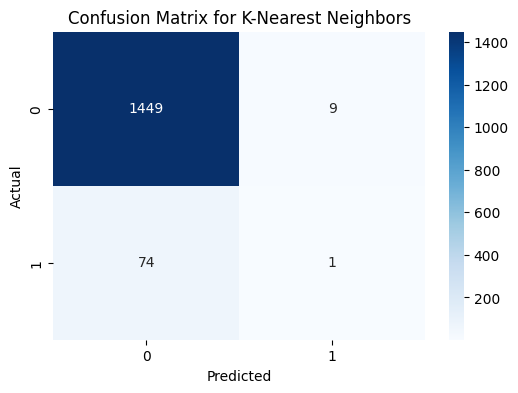

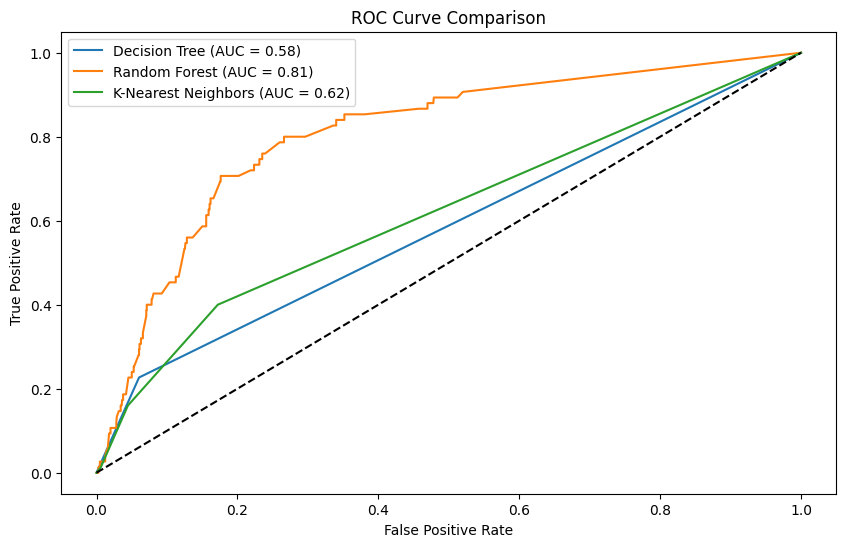

In [12]:
# Confusion Matrices
for model_name, metrics in results.items():
    plt.figure(figsize=(6, 4))
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ROC Curves
plt.figure(figsize=(10, 6))
for model_name, metrics in results.items():
    # Using the best model from models dictionary
    fpr, tpr, _ = roc_curve(y_test, models[model_name].predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {metrics['roc_auc_score']:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

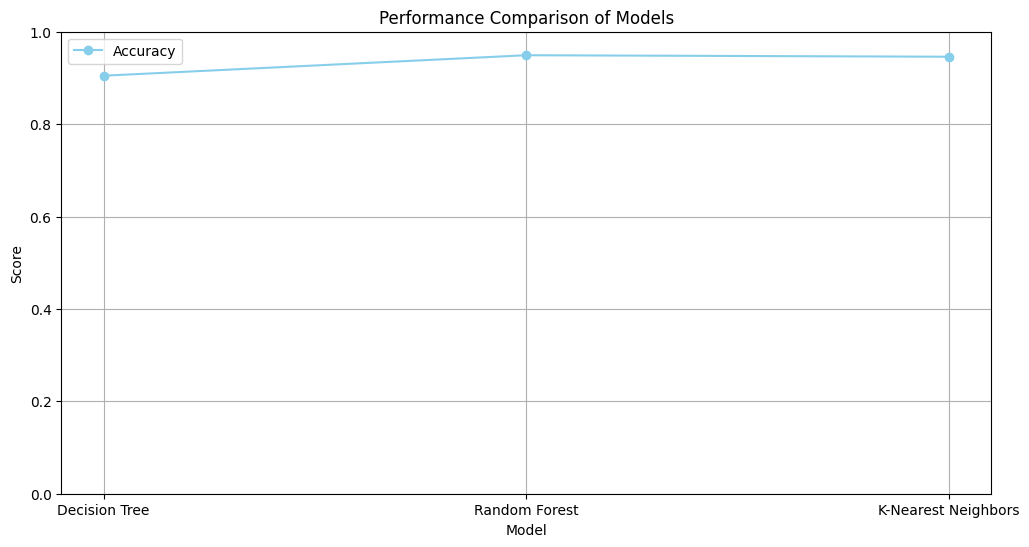

In [14]:
# Extract accuracy and ROC AUC scores for each model
model_names = list(results.keys())
accuracies = [results[model]['accuracy'] for model in model_names]

# Plotting the performance of models in a line chart
plt.figure(figsize=(12, 6))

# Line plot for Accuracy
plt.plot(model_names, accuracies, marker='o', linestyle='-', color='skyblue', label='Accuracy')

# Adding title and labels
plt.title('Performance Comparison of Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)  # Set consistent scale for better comparison
plt.legend()
plt.grid(True)
plt.show()
